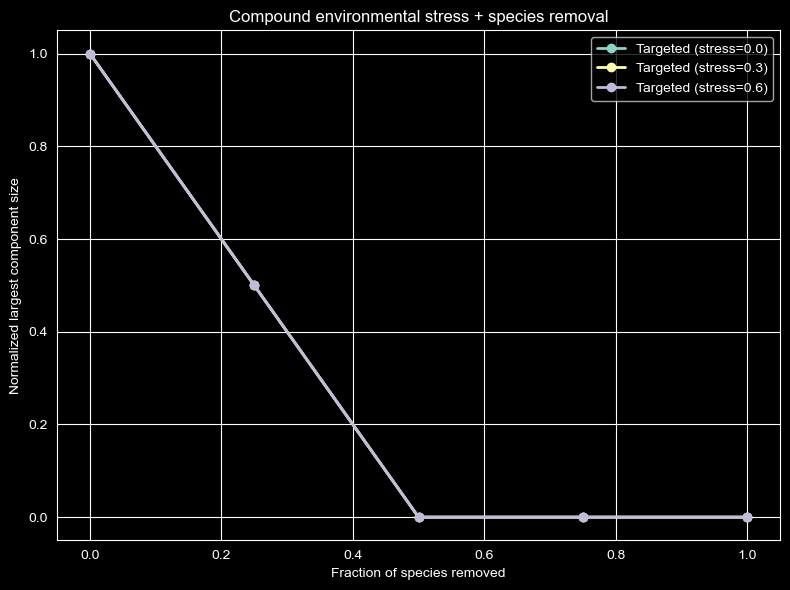

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from src.data.load_synthetic import load_synthetic_ecosystem
from src.network.build_layers import build_ecological_layer
from src.simulation.removal_strategies import (
    random_removal_order,
    targeted_removal_order
)
from src.simulation.environmental_stress import apply_environmental_stress
from src.metrics.robustness import robustness_curve

# =========================
# Load data & build network
# =========================
species, edges = load_synthetic_ecosystem(
    "data/raw/synthetic_ecosystem_v1.json"
)

G_base = build_ecological_layer(species, edges)

# =========================
# Stress levels to test
# =========================
stress_levels = [0.0, 0.3, 0.6]

plt.figure(figsize=(8, 6))

for stress in stress_levels:
    # Apply environmental stress
    G_stressed = apply_environmental_stress(G_base, stress)

    # Targeted removal under stress
    order_targeted = targeted_removal_order(G_stressed)
    f, lcc = robustness_curve(G_stressed, order_targeted)

    plt.plot(
        f, lcc,
        marker="o",
        linewidth=2,
        label=f"Targeted (stress={stress})"
    )

# =========================
# Plot formatting
# =========================
plt.xlabel("Fraction of species removed")
plt.ylabel("Normalized largest component size")
plt.title("Compound environmental stress + species removal")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


“Environmental stress reduces interaction strength in the food web, amplifying the impact of species loss and leading to earlier system fragmentation under targeted removal.”